In [1]:
!pip install -q scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Churn distribution

print("Churn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


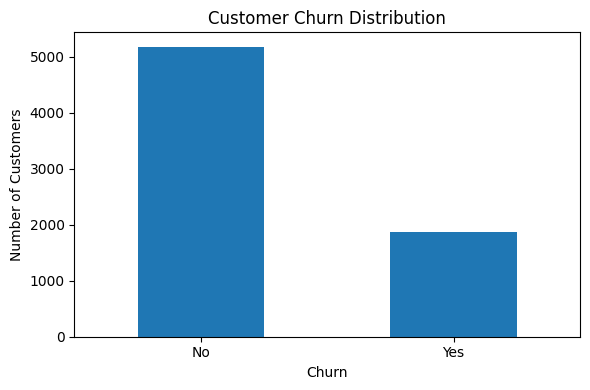

In [6]:
plt.figure(figsize=(6, 4))

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [7]:
# Churn by Contract Type

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


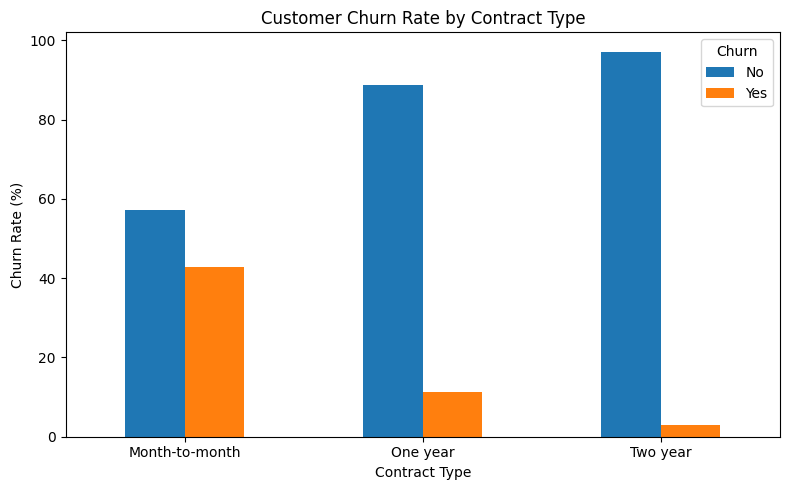

In [8]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

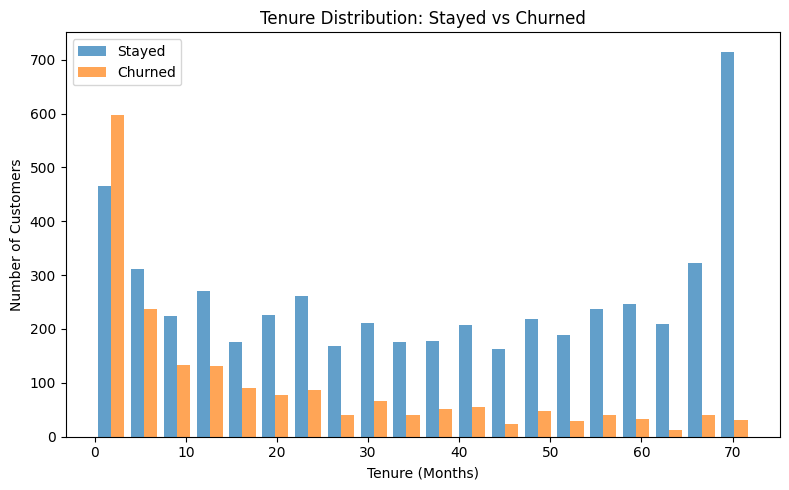

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(
    [df[df["Churn"] == "No"]["tenure"],
     df[df["Churn"] == "Yes"]["tenure"]],
    bins=20,
    label=["Stayed", "Churned"],
    alpha=0.7
)

plt.title("Tenure Distribution: Stayed vs Churned")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend()

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

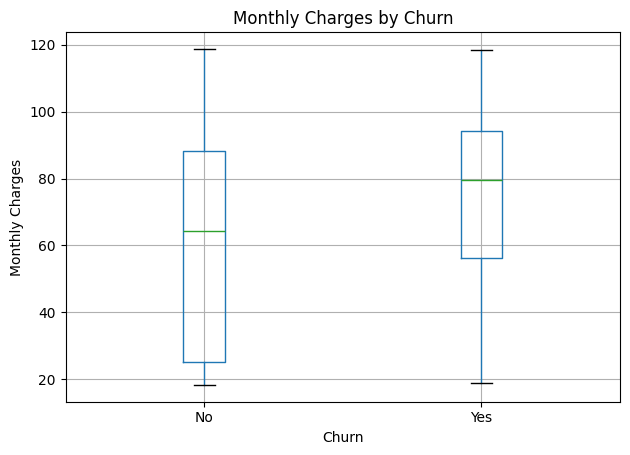

In [10]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

In [11]:
print(
    df.groupby("Churn")[["tenure", "MonthlyCharges"]]
      .mean()
      .round(2)
)

       tenure  MonthlyCharges
Churn                        
No      37.57           61.27
Yes     17.98           74.44


In [12]:
# Convert TotalCharges to numeric

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check missing values
print("Missing values after conversion:")
print(df.isnull().sum())

Missing values after conversion:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [13]:
# Fill missing TotalCharges with median

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [14]:
df = df.drop("customerID", axis=1)

print("New Dataset Shape:", df.shape)

New Dataset Shape: (7043, 20)


In [15]:
# Convert categorical variables into dummy variables

df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

print("Encoded Dataset Shape:", df_encoded.shape)

display(df_encoded.head())

Encoded Dataset Shape: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [16]:
# Separate features and target

X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5634, 30)
Testing Data: (1409, 30)


In [18]:
# Feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# Train Logistic Regression model

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

print("Model training completed successfully!")

Model training completed successfully!


In [20]:
# Model Evaluation

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 80.70%

Classification Report:
              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1035
        True       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



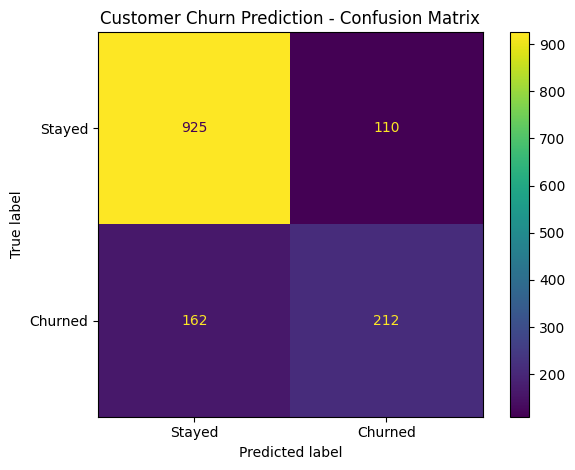

In [21]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()

plt.title("Customer Churn Prediction - Confusion Matrix")
plt.tight_layout()
plt.show()

In [22]:
# Feature importance from Logistic Regression

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

# Absolute coefficient for importance
feature_importance["Importance"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(15))

,Feature,Coefficient,Importance
1,tenure,-1.219639,1.219639
2,MonthlyCharges,-0.921369,0.921369
10,InternetService_Fiber optic,0.778760,0.778760
25,Contract_Two year,-0.588975,0.588975
3,TotalCharges,0.497246,0.497246
24,Contract_One year,-0.286473,0.286473
23,StreamingMovies_Yes,0.258653,0.258653
21,StreamingTV_Yes,0.258042,0.258042
9,MultipleLines_Yes,0.216356,0.216356
26,PaperlessBilling_Yes,0.181833,0.181833


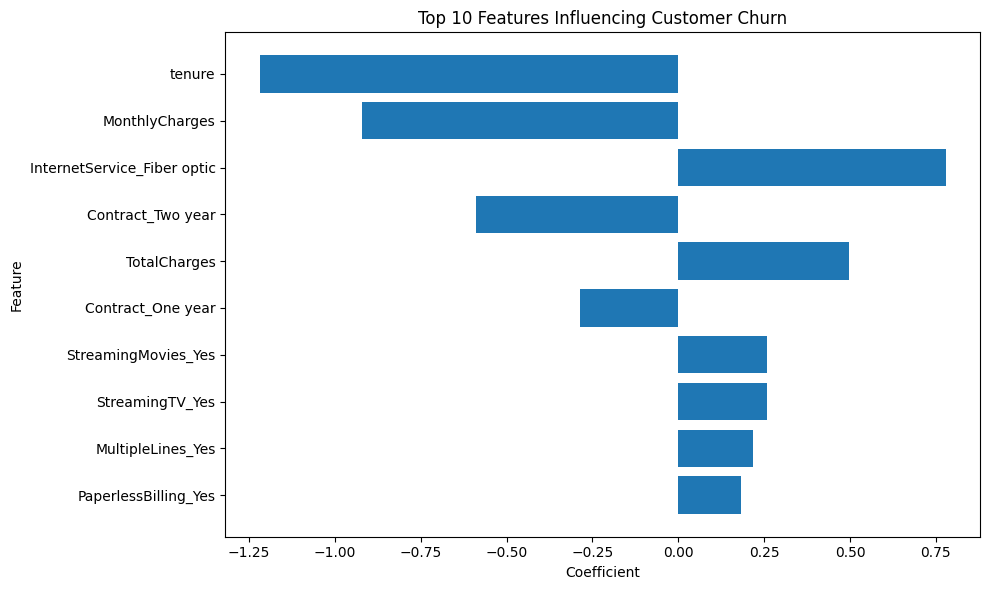

In [23]:
# Top 10 important features

top_features = feature_importance.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Customer Churn")

plt.tight_layout()
plt.show()

## Business Insights

1. The model was trained to predict whether a customer is likely to churn.

2. Customer contract type, tenure, monthly charges, and service-related
   features were analyzed to understand churn patterns.

3. Customers with different contract types showed different churn rates,
   indicating that contract structure is an important factor to analyze.

4. Tenure and monthly charges were also compared between customers who
   stayed and customers who churned.

5. Logistic Regression coefficients were used to identify features that
   contributed more strongly to the model's predictions.

6. The model evaluation was performed using accuracy, precision, recall,
   F1-score, and a confusion matrix.

7. These insights can help businesses identify customers who may be at
   higher risk of churn and design appropriate retention strategies.

## Conclusion

Customer Churn Prediction was performed using a Telco customer dataset.

The dataset was explored and preprocessed by handling missing values,
converting categorical variables into numerical features, and scaling
the data.

A Logistic Regression model was trained to predict customer churn.
The model was evaluated using accuracy, classification metrics, and a
confusion matrix.

Feature coefficients were also analyzed to understand which customer
attributes contributed more strongly to the model's predictions.

This project demonstrates how machine learning can be used to analyze
customer behavior and support data-driven customer retention strategies.

# 📊 Customer Churn Prediction

## Project Overview

Customer Churn Prediction is a machine learning project that analyzes
customer data and predicts whether a customer is likely to leave a service.

The project uses exploratory data analysis, data preprocessing, and
Logistic Regression to build a binary classification model.